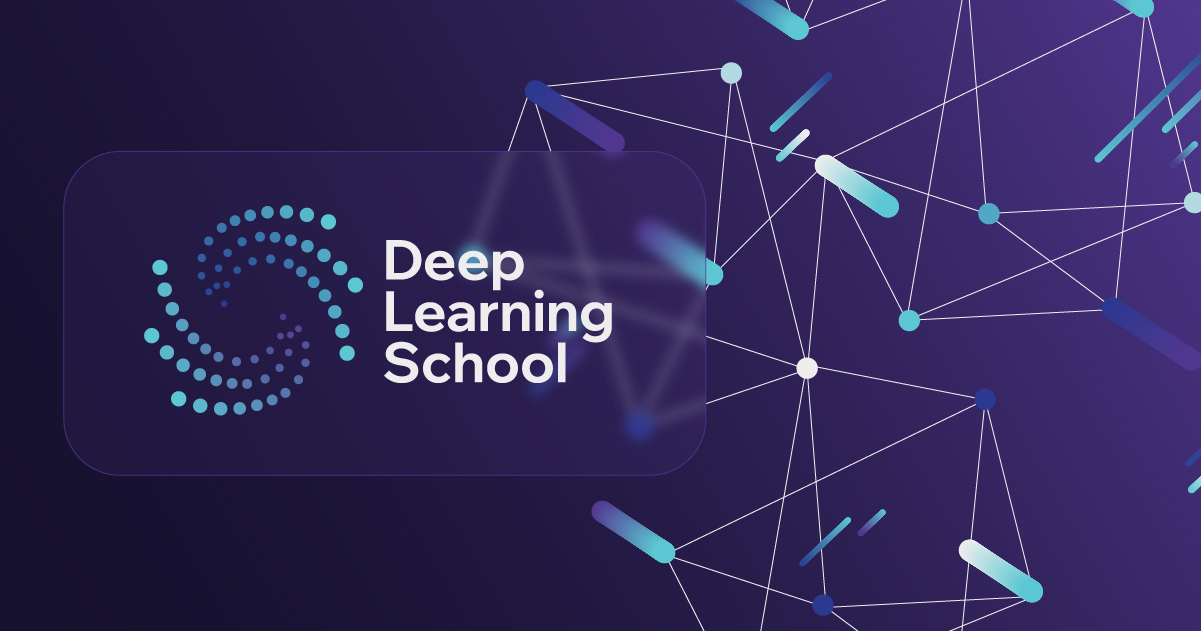


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

In [1]:
import os
# os.environ["TORCH_USE_CUDA_DSA"] = "1"
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

import lightning as L

from lightning.pytorch.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

from torch.utils.data import DataLoader
from torchvision.utils import make_grid

%matplotlib inline

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [2]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

100%|██████████| 112M/112M [00:04<00:00, 25.4MB/s] 

Extracting files...


Path to dataset files: C:\Users\Efim Plotnikov\.cache\kagglehub\datasets\jessicali9530\lfw-dataset\versions\4


In [3]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

100%|██████████| 6.49M/6.49M [00:01<00:00, 6.65MB/s]

Extracting files...


Path to dataset files: C:\Users\Efim Plotnikov\.cache\kagglehub\datasets\averkij\lfw-attributes\versions\1


In [4]:
DATASET_PATH ="kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "kaggle/input/lfw-attributes/lfw_attributes.txt"

In [5]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])
    assert len(df_attrs) > 0, "Не удалось загрузить атрибуты из файла!"

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    assert len(photo_ids) > 0, "Не найдены изображения в указанной папке!"

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [ ]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

IMG_SIZE = 128
images, attrs = fetch_dataset(dimx=IMG_SIZE, dimy=IMG_SIZE)


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val = train_test_split(images, test_size=0.2, random_state=42)

def to_tensor_dataset(X):
    X = torch.tensor(X).permute(0,3,1,2).float() / 255.0
    return data_utils.TensorDataset(X, X)

train_dataset = to_tensor_dataset(X_train)
val_dataset = to_tensor_dataset(X_val)

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



[image.png](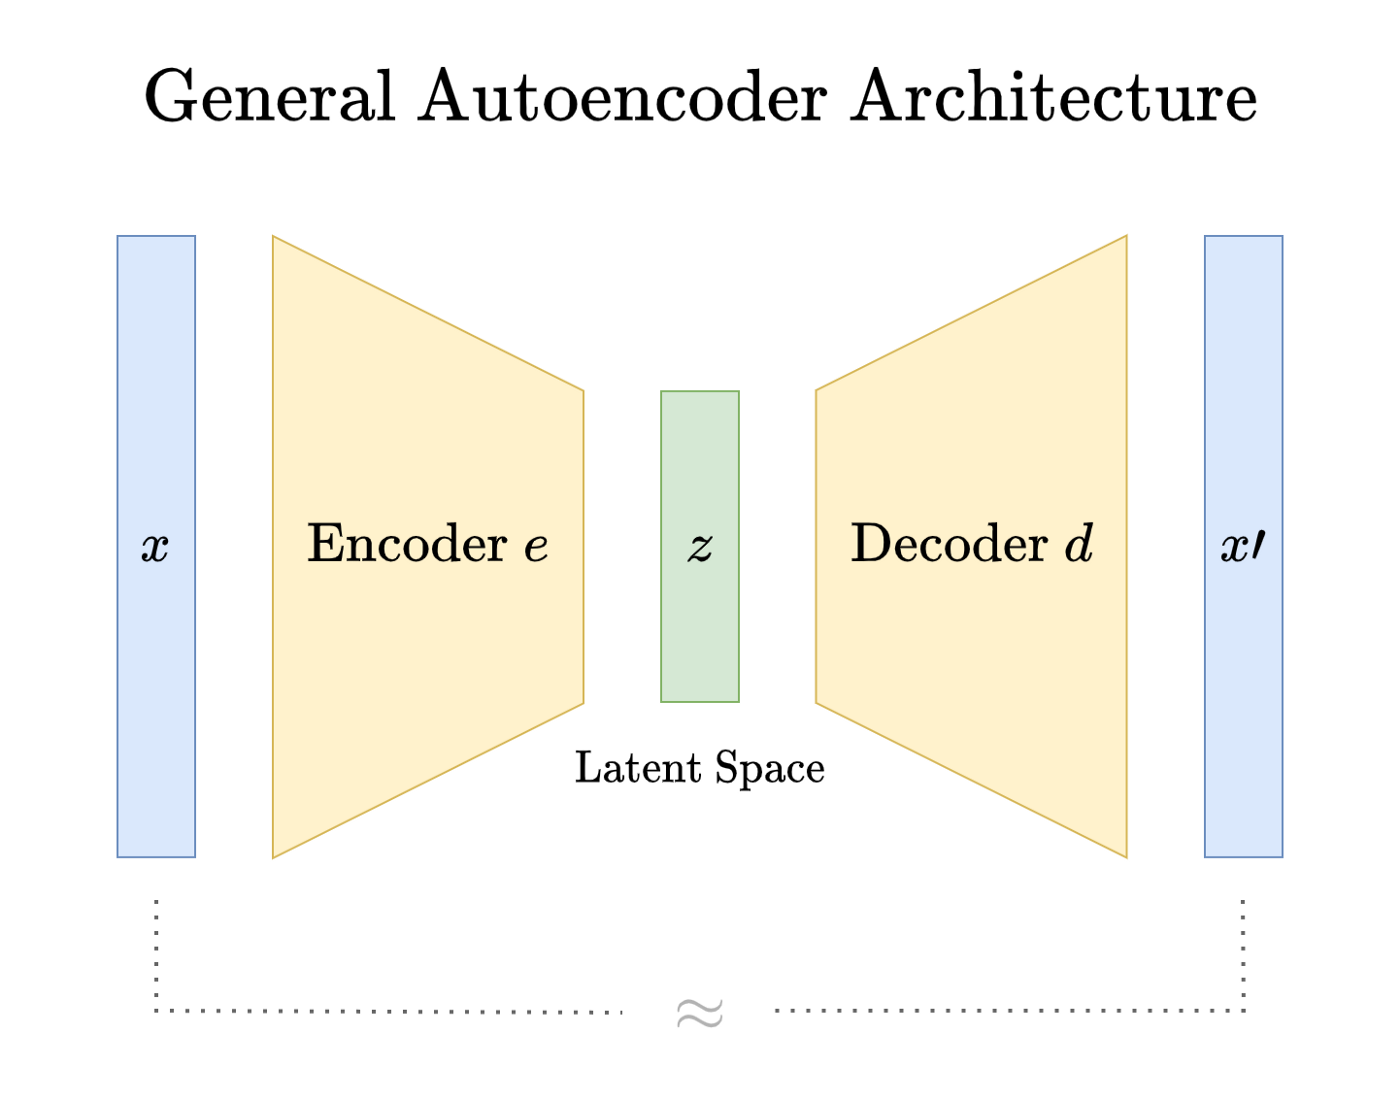)

In [ ]:
dim_code = 1000

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

**Буду делать из конволюционных блоков в несколько слоёв**

In [ ]:
# Эти блоки взяты почти 1-1 из UNet домашки

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.downsampling = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=2, padding=padding)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = self.downsampling(x)
        return x


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, tail_activation = True):
        super(DecoderBlock, self).__init__() 
        
        self.upsampling = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.layers = nn.Sequential()

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = in_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        if not tail_activation:
            del self.layers[-2:]

    def forward(self, x):
        x = self.upsampling(x)
        
        for layer in self.layers:
            x = layer(x)
        
        return x
    

Собираем автоэнкодер на конволюциях

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, dim_code, conv_channels=16):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            EncoderBlock(in_channels=3,             out_channels=conv_channels, depth=2), # IMG_SIZE / 2
            EncoderBlock(in_channels=conv_channels, out_channels=conv_channels, depth=2), # IMG_SIZE / 4
            EncoderBlock(in_channels=conv_channels, out_channels=conv_channels, depth=2), # IMG_SIZE / 8
            EncoderBlock(in_channels=conv_channels, out_channels=conv_channels, depth=2), # IMG_SIZE / 16
            nn.Flatten(1),
            nn.Linear(in_features=conv_channels * (IMG_SIZE // 16) ** 2, out_features=dim_code),
        )

        self.decoder = nn.Sequential(
            nn.Linear(in_features=dim_code, out_features=8 * 8 * conv_channels),
            nn.Unflatten(dim=1, unflattened_size=(conv_channels, 8, 8)),
            DecoderBlock(in_channels=conv_channels, out_channels=conv_channels, depth=2),
            DecoderBlock(in_channels=conv_channels, out_channels=conv_channels, depth=2),
            DecoderBlock(in_channels=conv_channels, out_channels=conv_channels // 2, depth=2),
            DecoderBlock(in_channels=conv_channels // 2, out_channels=3, depth=2, tail_activation=False),
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        
        return reconstruction, latent_code

In [ ]:
criterion = nn.MSELoss()
autoencoder = Autoencoder(dim_code=dim_code)

Быстрая проверка размерностей

In [ ]:
from torchinfo import summary
summary(autoencoder, input_size=(1,3,IMG_SIZE,IMG_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [1, 3, 128, 128]          --
├─Sequential: 1-1                        [1, 1000]                 --
│    └─EncoderBlock: 2-1                 [1, 16, 64, 64]           --
│    │    └─ModuleList: 3-1              --                        2,832
│    │    └─Conv2d: 3-2                  [1, 16, 64, 64]           2,320
│    └─EncoderBlock: 2-2                 [1, 16, 32, 32]           --
│    │    └─ModuleList: 3-3              --                        4,704
│    │    └─Conv2d: 3-4                  [1, 16, 32, 32]           2,320
│    └─EncoderBlock: 2-3                 [1, 16, 16, 16]           --
│    │    └─ModuleList: 3-5              --                        4,704
│    │    └─Conv2d: 3-6                  [1, 16, 16, 16]           2,320
│    └─EncoderBlock: 2-4                 [1, 16, 8, 8]             --
│    │    └─ModuleList: 3-7              --                        

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

---

**Учить модель буду в lightning чтобы выводить всё красиво на tensorboard**

In [ ]:
%load_ext tensorboard
%tensorboard --logdir lightning_logs --port 6006

In [5]:
# Обертка над моделью для обучения в Lightning

class LitAutoencoder(L.LightningModule):
    def __init__(self, model, loss, lr=1e-3):
        super().__init__()
        self.model = model
        self.lr = lr
        self.loss = loss

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)[0]
        loss = self.loss(pred, y)
        self.log("train/loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)[0]
        loss = self.loss(pred, y)
        self.log("val/loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

Callback для мониторинга качества генерации картинок в процессе обучения (на tensorboard)

In [4]:
class ImageLoggerCallback(L.Callback):
    def __init__(self, val_samples, log_every_n_epochs=1):
        self.val_samples = val_samples
        self.log_every_n_epochs = log_every_n_epochs

        x = next(iter(val_samples))
        self.fixed_x = x[0]


    def on_validation_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch
        if epoch % self.log_every_n_epochs != 0:
            return

        x = self.fixed_x.to(pl_module.device)

        with torch.no_grad():
            pred = pl_module(x)[0]

        img_gt   = x[:4].cpu()
        img_pred = pred[:4].cpu()

        # GT сверху, реконструкция снизу
        imgs = torch.cat([img_gt, img_pred], dim=2)
        grid = make_grid(imgs, nrow=4)

        pl_module.logger.experiment.add_image("GT_vs_reconstruction", grid, global_step=epoch)

Далее учим с сохранением лучшей эпохи

In [ ]:
# Обучение AE

torch.set_float32_matmul_precision('high')

EXP_NAME = "autoencoder"
EXP_VERSION = 1

checkpoint_cb = ModelCheckpoint(
    dirpath=f"checkpoints/{EXP_NAME}/v{EXP_VERSION}",
    filename=f"{EXP_NAME}-{{epoch:03d}}",
    save_top_k=1,
    monitor="val/loss",
    mode="min",
)

val_dl_for_logging = DataLoader(val_dataset, batch_size=8, shuffle=False)
logger_cb = ImageLoggerCallback(val_dl_for_logging, log_every_n_epochs=1)

model = LitAutoencoder(autoencoder, criterion, lr=1e-3).to(DEVICE)

trainer = L.Trainer(
    max_epochs=900,
    logger = TensorBoardLogger("lightning_logs", name=EXP_NAME, version=EXP_VERSION),
    log_every_n_steps=5,
    callbacks=[checkpoint_cb, logger_cb],
)

train_dl = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=8, persistent_workers=True)
val_dl   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=8, persistent_workers=True)
trainer.fit(model, train_dl, val_dl)

Обучение со всеми графиками и прогрессом было на tensorboard, вырезки по лоссам:


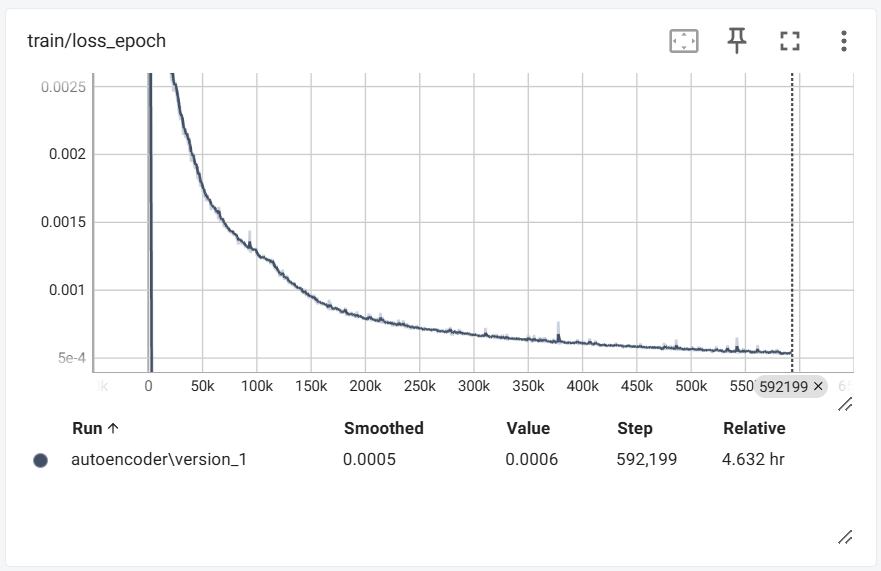

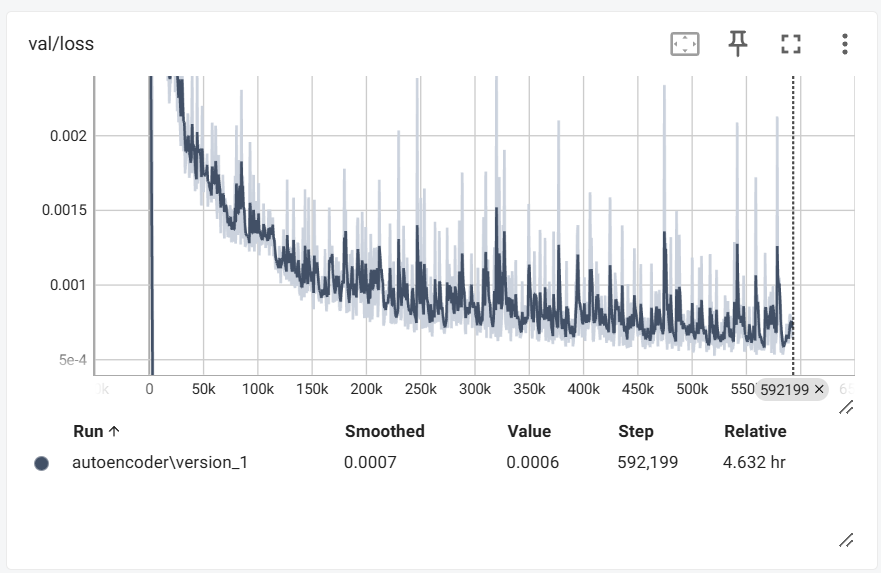

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

c:\Users\efimplotnikov\Projects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


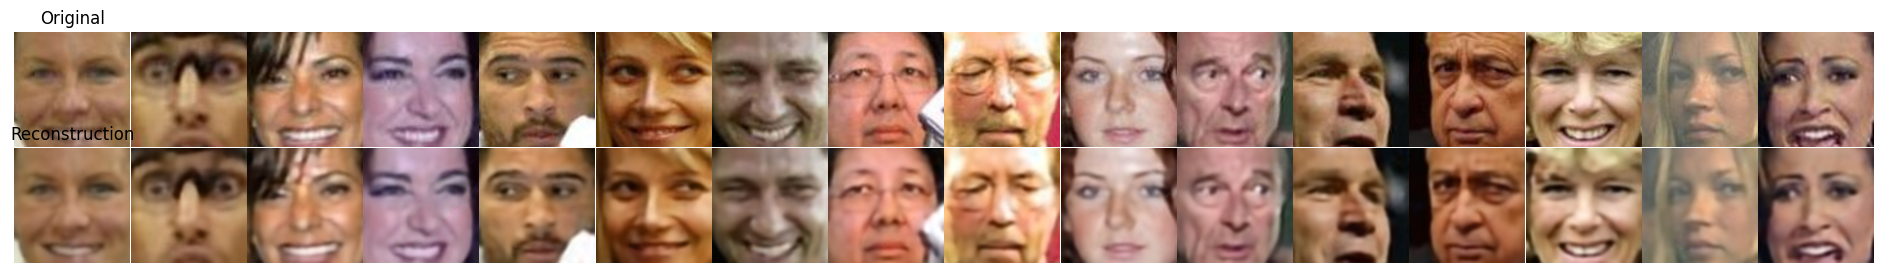

In [371]:
best_autoencoder = LitAutoencoder.load_from_checkpoint(
    'checkpoints/autoencoder/v1/autoencoder-epoch=790.ckpt',
    model=Autoencoder(dim_code=dim_code), 
    loss=criterion, 
    lr=1e-3
).to(DEVICE)

best_autoencoder.eval()

for X, _ in val_dl:
    with torch.no_grad():
        x_reconstructed, x_latent = best_autoencoder(X.to(DEVICE))
        x_reconstructed = x_reconstructed.cpu()

    n = len(X)
    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))

    for i in range(n):
        axes[0, i].imshow(X[i].permute(1,2,0))
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original")

        axes[1, i].imshow(x_reconstructed[i].permute(1,2,0).clamp(0, 1))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstruction")

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()
    break

Что вы можете сказать про результат?

**Результат превосходный. Мыльно, но правдиво.**

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [74]:
def plot_generated_images(output, square_size=5, title="Generation"):
    n = len(output)
    fig, axes = plt.subplots(square_size, square_size, figsize=(square_size, square_size))

    for i in range(square_size ** 2):
        if i >= n:
            break
        
        ax = axes[i % square_size, i // square_size]
        ax.imshow(output[i].cpu().permute(1,2,0).clamp(0, 1))
        ax.axis("off")
        if i == 0:
            ax.set_title(title)

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


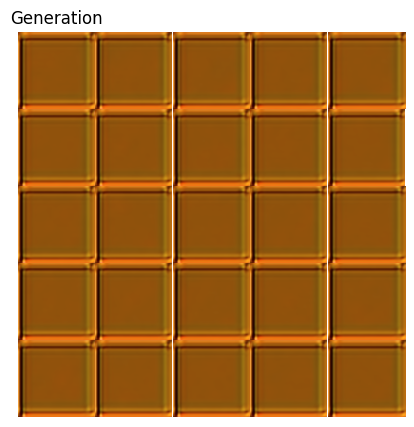

In [289]:
# сгенерируем 25 рандомных векторов размера latent_space
z = np.random.randn(25, dim_code)

with torch.no_grad():
    output = best_autoencoder.model.decoder(torch.tensor(z).float().to(DEVICE))

plot_generated_images(output, square_size=5)


**Получилась шоколадка.** Явно распределение в латентном пространстве не похоже на $N(0,1)$.

Надо корректировать генерацию.

In [293]:
# посчитаем средние и стандартные отклонения по каждому из измерений латентного пространства
# для этого пропускаем весь валидационный датасет через энкодер
with torch.no_grad():
    _, val_latents = best_autoencoder(val_dataset[:][0].to(DEVICE))

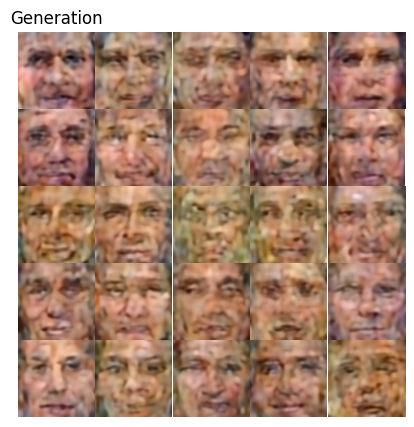

In [307]:
latents_mean = val_latents.mean(dim=0).cpu().numpy()
latents_std = val_latents.std(dim=0).cpu().numpy() + 1e-6

# теперь генерируем чуть более правдоподобные сэмплы, 
# предполагая что оно там все еще нормальное но не стандартное
z = np.random.randn(25, dim_code) * latents_std + latents_mean

with torch.no_grad():
    output = best_autoencoder.model.decoder(torch.tensor(z).float().to(DEVICE))

plot_generated_images(output, square_size=5)

**Получились зомби,** но в целом это уже лица, приятно посмотреть.


Ещё похоже на аватарку героя из Disco Elysium, пока он в зеркало не посмотрел:


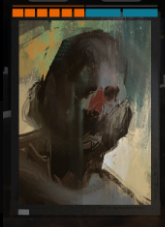

Результат далёк от ожиданий, это говорит о том что гипотеза 
о нормальности распределения в латентном пространстве терпит крах.

Вероятно, там по факту:
- ненормальное распределение
- есть созависимые признаки

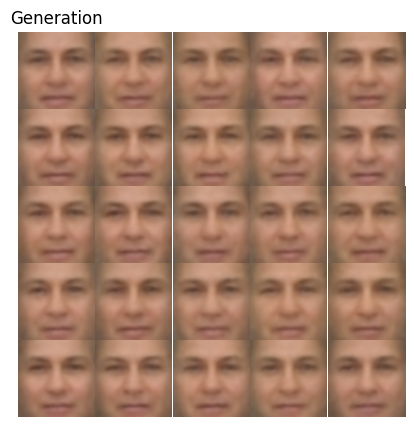

In [314]:
# можно уменьшить разброс чтобы еще больше усреднить
z = np.random.randn(25, dim_code) * latents_std/8 + latents_mean

with torch.no_grad():
    output = best_autoencoder.model.decoder(torch.tensor(z).float().to(DEVICE))

plot_generated_images(output, square_size=5)

Ближе к мат ожиданию получаются максимально соевые лица практически без отличий

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

Посмотрим, что там про улыбки в разметке

In [337]:
print([x for x in attrs.columns if 'smil' in x.lower()])

['Smiling']


И что там с распределением улыбчивости

In [340]:
attrs['Smiling'].agg(['mean', 'std', 'min', 'max', 'count'])

mean        -0.150700
std          1.127722
min         -2.686594
max          2.839994
count    13143.000000
Name: Smiling, dtype: float64

Судя по всему, значения за пределами [-1; 1] относятся к очень улыбчивым или очень грустным. Логично с ними и работать:

In [354]:
smiling_images = np.stack([im for (im, attr) in zip(images, attrs['Smiling']) if attr > 2.0])
smile_dataset = to_tensor_dataset(smiling_images)
print("Smiling: ", len(smile_dataset))

sad_images = np.stack([im for (im, attr) in zip(images, attrs['Smiling']) if attr < -2.0])
sad_dataset = to_tensor_dataset(sad_images)
print("Sad: ", len(sad_dataset))

Smiling:  342
Sad:  254


Пакуем этих людей в латентное пространство, чтобы они поулыбались там

In [355]:
with torch.no_grad():
    _, smiling_latents = best_autoencoder(smile_dataset[:][0].to(DEVICE))
    _, sad_latents = best_autoencoder(sad_dataset[:][0].to(DEVICE))

Считаем направление от грустного к улыбчивому 

In [357]:
delta_smile = (smiling_latents.mean(dim=0).cpu().numpy() - sad_latents.mean(dim=0).cpu().numpy())

**Улыбаем грустных**

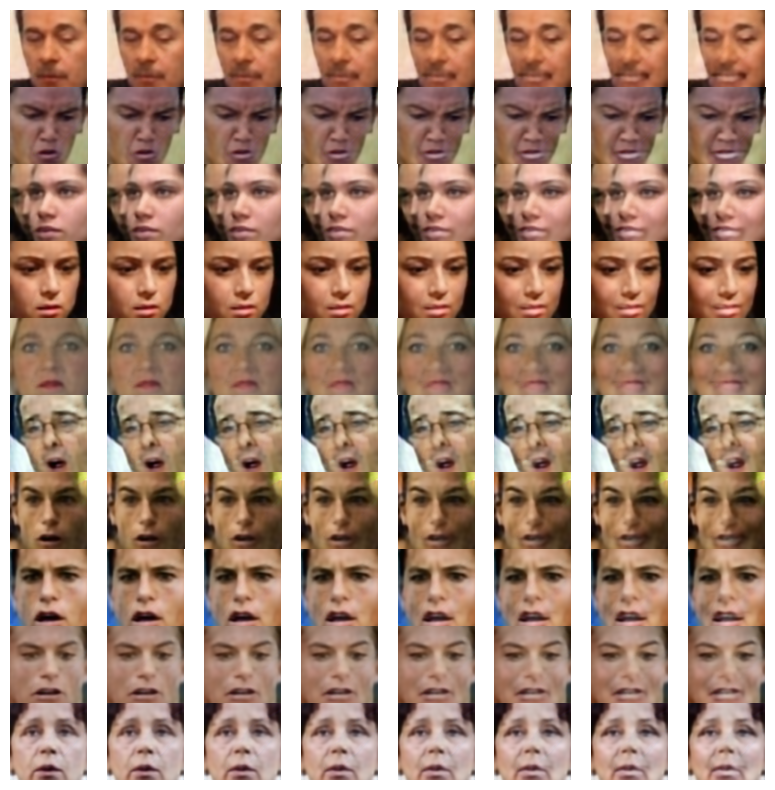

In [ ]:
SMILE_STEPS = 8
CANDIDATES = 10

fig, axes = plt.subplots(CANDIDATES, SMILE_STEPS, figsize=(10, 10))

saddy_latents = sad_latents[:CANDIDATES]

with torch.no_grad():
    
    for smile_step in range(SMILE_STEPS):
        
        smile_coeff = 2 * smile_step / SMILE_STEPS

        smiling_saddy_latents = saddy_latents + torch.tensor(delta_smile).float().to(DEVICE) * smile_coeff
        smiling_saddies = best_autoencoder.model.decoder(smiling_saddy_latents.to(DEVICE)).cpu()

        n = len(smiling_saddies)

        for i in range(n):
            axes[i, smile_step].imshow(smiling_saddies[i].permute(1,2,0).clamp(0, 1))
            axes[i, smile_step].axis("off")


plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [5]:
from torchvision import transforms

batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_val = train_test_split(train_dataset, test_size=0.2, random_state=42)

train_loader = torch.utils.data.DataLoader(dataset=X_train, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=X_val, batch_size=batch_size, shuffle=False)

img, label = train_dataset[0]
print(img.shape)

_, IMG_SIZE, _ = img.shape

torch.Size([1, 28, 28])


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [ ]:
class VariationEncoder(nn.Module):
    def __init__(self, conv_channels, img_size, out_channels, in_channels=1) -> None:
        super(VariationEncoder, self).__init__()

        self.backbone = nn.Sequential(
            EncoderBlock(in_channels=in_channels,   out_channels=conv_channels, depth=2), # IMG_SIZE / 2
            EncoderBlock(in_channels=conv_channels, out_channels=conv_channels, depth=2), # IMG_SIZE / 4
            nn.Flatten(1),
        )

        features = conv_channels * (img_size // 4) ** 2
        self.fc_mu = nn.Linear(features, out_channels)
        self.fc_logvar = nn.Linear(features, out_channels)

    def forward(self, x):
        features = self.backbone(x)
        mean = self.fc_mu(features)
        logvar = self.fc_logvar(features)
        return mean, logvar
    

class VAE(nn.Module):

    def __init__(self, dim_code, img_size, in_channels=1, out_channels=1, conv_channels=16):
        super(VAE, self).__init__()
        
        self.encoder = VariationEncoder(conv_channels, img_size, out_channels=dim_code, in_channels=in_channels)

        compressed_square_size = img_size // 4

        self.decoder = nn.Sequential(
            nn.Linear(in_features=dim_code, out_features=compressed_square_size ** 2 * conv_channels),
            nn.Unflatten(dim=1, unflattened_size=(conv_channels, compressed_square_size, compressed_square_size)),
            DecoderBlock(in_channels=conv_channels, out_channels=conv_channels, depth=2),
            DecoderBlock(in_channels=conv_channels, out_channels=out_channels, depth=2, tail_activation=False),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            return torch.randn_like(mu) * torch.exp(logsigma) + mu
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def forward(self, x):
        mean, logvar = self.encoder(x)
        latent_code = self.gaussian_sampler(mean, logvar)
        reconstruction = self.decoder(latent_code)
        
        return reconstruction, mean, logvar

MNIST_LATENT_DIMENSIONS = 8
vae = VAE(dim_code=MNIST_LATENT_DIMENSIONS, img_size=IMG_SIZE)
from torchinfo import summary
summary(vae, input_size=(1,1,IMG_SIZE,IMG_SIZE))

Layer (type:depth-idx)                        Output Shape              Param #
VAE                                           [1, 1, 28, 28]            --
├─VariationEncoder: 1-1                       [1, 8]                    --
│    └─Sequential: 2-1                        [1, 784]                  --
│    │    └─EncoderBlock: 3-1                 [1, 16, 14, 14]           4,864
│    │    └─EncoderBlock: 3-2                 [1, 16, 7, 7]             7,024
│    │    └─Flatten: 3-3                      [1, 784]                  --
│    └─Linear: 2-2                            [1, 8]                    6,280
│    └─Linear: 2-3                            [1, 8]                    6,280
├─Sequential: 1-2                             [1, 1, 28, 28]            --
│    └─Linear: 2-4                            [1, 784]                  7,056
│    └─Unflatten: 2-5                         [1, 16, 7, 7]             --
│    └─DecoderBlock: 2-6                      [1, 16, 14, 14]           --
│    

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [8]:
def KL_divergence(mu, logsigma):
    # mu, logsigma: (B, dimZ)
    kl = -0.5 * torch.sum(
        1 + 2 * logsigma - mu**2 - torch.exp(2 * logsigma),
        dim=1
    )
    return kl.mean()

def log_likelihood(x, reconstruction):
    bce = F.binary_cross_entropy_with_logits(
        reconstruction, x,
        reduction="none"
    )
    return bce.view(bce.size(0), -1).sum(dim=1).mean()

def loss_vae(x, mu, logsigma, reconstruction):
    recon_loss = log_likelihood(x, reconstruction)
    kl = KL_divergence(mu, logsigma)
    return recon_loss + kl

И обучим модель:

In [9]:
EXP_NAME = "vae"
EXP_VERSION = 1

checkpoint_cb = ModelCheckpoint(
    dirpath=f"checkpoints/{EXP_NAME}/v{EXP_VERSION}",
    filename=f"{EXP_NAME}-{{epoch:03d}}",
    save_top_k=3,
    monitor="val/loss",
    mode="min",
)

val_dl_for_logging = DataLoader(X_val, batch_size=8, shuffle=False)
logger_cb = ImageLoggerCallback(val_dl_for_logging, log_every_n_epochs=1)

In [ ]:
# Обертка над моделью для обучения в Lightning

class LitVAE(L.LightningModule):
    def __init__(self, model, loss, lr=1e-3):
        super().__init__()
        self.model = model
        self.lr = lr
        self.loss = loss

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch 
        pred, mu, logsigma = self(x)
        loss = self.loss(x, mu, logsigma, pred)
        self.log("train/loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        pred, mu, logsigma = self(x)
        loss = self.loss(x, mu, logsigma, pred)
        self.log("val/loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

model = LitVAE(model=vae, loss=loss_vae, lr=1e-3).to(DEVICE)
print(f"Model is ready for training on {DEVICE}")

Model is ready for training on cuda


In [11]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [ ]:
trainer = L.Trainer(
    max_epochs=900,
    logger = TensorBoardLogger("lightning_logs", name=EXP_NAME, version=EXP_VERSION),
    log_every_n_steps=5,
    callbacks=[checkpoint_cb, logger_cb],
)

trainer.fit(model, train_loader, val_loader)

График лосса из tensorboard:

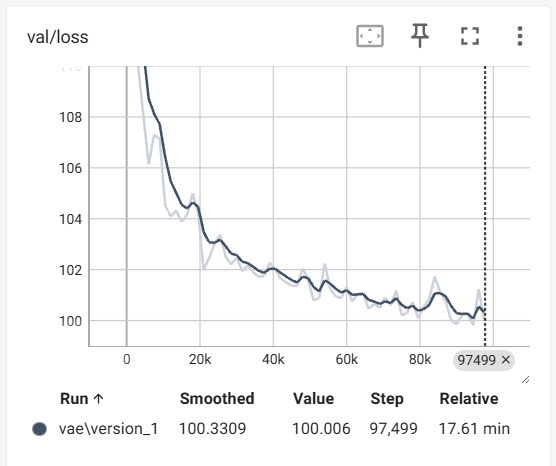

**Что-то обучилось, загружаем лучший чекпоинт**

In [ ]:
best_vae = LitVAE.load_from_checkpoint(
    'checkpoints/vae/v1/vae-epoch=065.ckpt',
    model=VAE(dim_code=MNIST_LATENT_DIMENSIONS, img_size=IMG_SIZE),
    loss=loss_vae, 
    lr=1e-3
).to(DEVICE)

best_vae.eval()
print("Checkpoint loaded")

Checkpoint loaded


c:\Users\Efim Plotnikov\PycharmProjects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

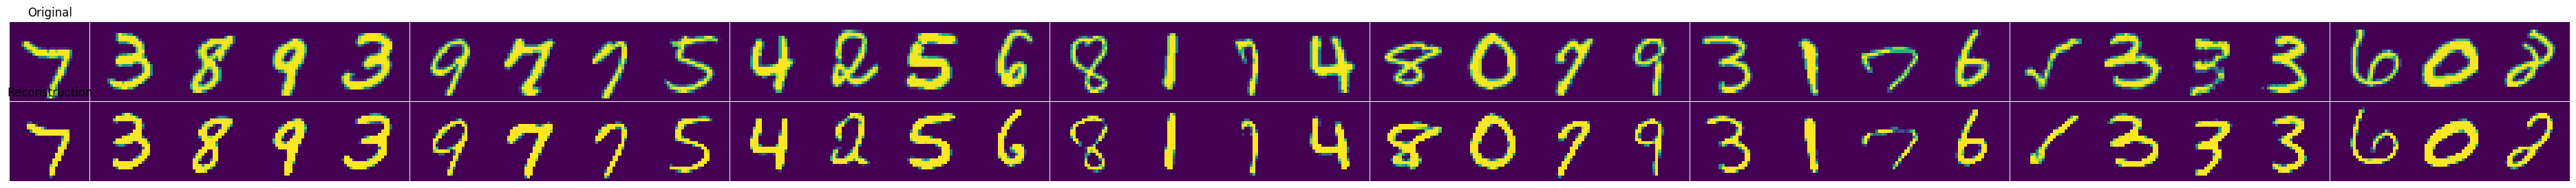

In [23]:
for X, _ in val_loader:
    with torch.no_grad():
        x_reconstructed = best_vae(X.to(DEVICE))[0]
        x_reconstructed = x_reconstructed.cpu()

    n = len(X)
    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))

    for i in range(n):
        axes[0, i].imshow(X[i].permute(1,2,0))
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original")

        axes[1, i].imshow(x_reconstructed[i].permute(1,2,0).clamp(0, 1))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstruction")

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()
    break

**Картинки восстанавливаются хорошо**

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

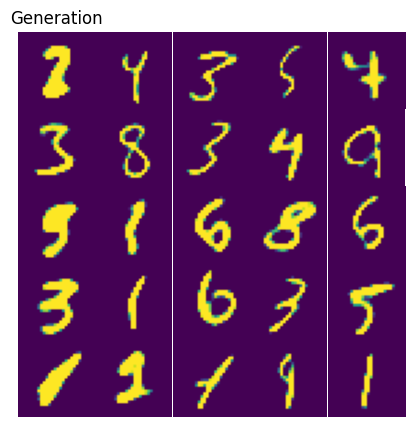

In [ ]:
z = np.array([np.random.normal(0, 1, MNIST_LATENT_DIMENSIONS) for i in range(25)])

with torch.no_grad():
    output = best_vae.model.decoder(torch.tensor(z).float().to(DEVICE))

plot_generated_images(output, square_size=5)

**Картинки гораздо более адекватные чем из AE, все числа различимы, зомби-чисел нет.**

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок ~~лиц~~ циферок выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

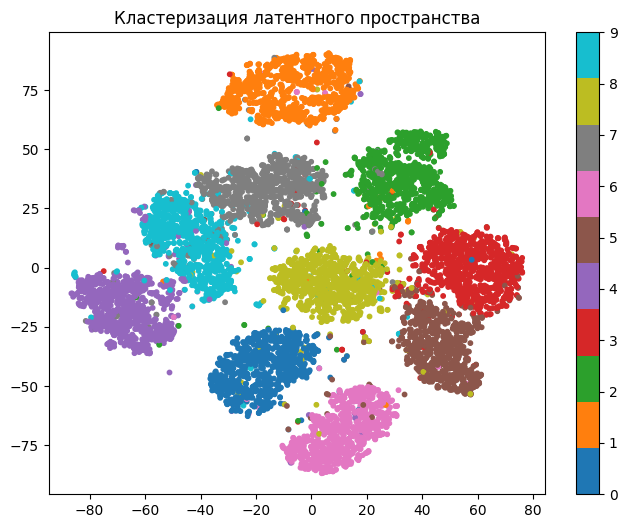

In [40]:
from sklearn.manifold import TSNE

latents_list = []
labels_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)             
        mean, logvar = best_vae.model.encoder(X_batch)      
        latents_list.append(mean.cpu())
        labels_list.append(y_batch)

latents = torch.cat(latents_list, dim=0).numpy()
labels = torch.cat(labels_list, dim=0).numpy()

tsne = TSNE(n_components=2, random_state=42)
latents_2d = tsne.fit_transform(latents)

plt.figure(figsize=(8,6))
scatter = plt.scatter(latents_2d[:,0], latents_2d[:,1], c=labels, cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(10))
plt.title("Кластеризация латентного пространства")
plt.show()

Что вы думаете о виде латентного представления?

**Кластеры чётко оформлены, лишь небольшая доля точек выпадает за границы пятен. Такое распределение легко поддается классификации с небольшой ошибкой.**

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [61]:
# Encoder со знанием о метке класса
class ConditionalVariationEncoder(nn.Module):
    def __init__(self, conv_channels, img_size, n_classes, out_channels, in_channels=1) -> None:
        super(ConditionalVariationEncoder, self).__init__()

        self.n_classes = n_classes
        self.backbone = nn.Sequential(
            EncoderBlock(in_channels=in_channels,   out_channels=conv_channels, depth=2), # IMG_SIZE / 2
            EncoderBlock(in_channels=conv_channels, out_channels=conv_channels, depth=2), # IMG_SIZE / 4
            nn.Flatten(1),
        )

        features = conv_channels * (img_size // 4) ** 2
        self.fc_mu = nn.Linear(features + n_classes, out_channels)
        self.fc_logvar = nn.Linear(features + n_classes, out_channels)

    def forward(self, x, class_num):
        features = self.backbone(x)
        # подмешиваем информацию о цифре
        class_ohe = F.one_hot(class_num, num_classes=self.n_classes).float()
        features = torch.cat([features, class_ohe], dim=1)
        mean = self.fc_mu(features)
        logvar = self.fc_logvar(features)
        return mean, logvar


# Целиковый CVAE
class CVAE(nn.Module):

    def __init__(self, dim_code, img_size, n_classes, in_channels=1, out_channels=1, conv_channels=16):
        super(CVAE, self).__init__()
        
        self.n_classes = n_classes
        self.encoder = ConditionalVariationEncoder(conv_channels, img_size, out_channels=dim_code, in_channels=in_channels, n_classes=n_classes)

        compressed_square_size = img_size // 4

        self.decoder = nn.Sequential(
            nn.Linear(in_features=dim_code + n_classes, out_features=compressed_square_size ** 2 * conv_channels),
            nn.Unflatten(dim=1, unflattened_size=(conv_channels, compressed_square_size, compressed_square_size)),
            DecoderBlock(in_channels=conv_channels, out_channels=conv_channels, depth=2),
            DecoderBlock(in_channels=conv_channels, out_channels=out_channels, depth=2, tail_activation=False),
        )

    def encode(self, x, class_num):
        return self.encoder(x, class_num)

    def decode(self, z, class_num):
        class_ohe = F.one_hot(class_num, num_classes=self.n_classes).float()
        z_cat = torch.cat([z, class_ohe], dim=1)
        return self.decoder(z_cat)

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            return torch.randn_like(mu) * torch.exp(logsigma) + mu
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def forward(self, x, class_num): 
        mean, logvar = self.encode(x, class_num)
        latent_code = self.gaussian_sampler(mean, logvar)
        reconstruction = self.decode(latent_code, class_num)
        
        return reconstruction, mean, logvar


MNIST_CLASSES = 10
MNIST_LATENT_DIMENSIONS = 8
cvae = CVAE(dim_code=MNIST_LATENT_DIMENSIONS, img_size=IMG_SIZE, n_classes=MNIST_CLASSES)

# Sanity check
from torchinfo import summary
dummy_x = torch.randn(1, 1, IMG_SIZE, IMG_SIZE)
dummy_y = torch.tensor([0])
summary(cvae, input_data=(dummy_x, dummy_y))


# Обертка над моделью для обучения в Lightning
class LitСVAE(L.LightningModule):
    def __init__(self, model, loss, lr=1e-3):
        super().__init__()
        self.model = model
        self.lr = lr
        self.loss = loss

    def forward(self, x, y=None):
        if y is None:
            y = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        return self.model(x, y)

    def training_step(self, batch, batch_idx):
        x, y = batch 
        pred, mu, logsigma = self.model(x, y)
        loss = self.loss(x, mu, logsigma, pred)
        self.log("train/loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        pred, mu, logsigma = self.model(x, y)
        loss = self.loss(x, mu, logsigma, pred)
        self.log("val/loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


# Модель под обучение
model = LitСVAE(model=cvae, loss=loss_vae, lr=1e-3).to(DEVICE)
print(f"CVAE Model is ready for training on {DEVICE}")

CVAE Model is ready for training on cuda


In [ ]:
EXP_NAME = "cvae"
EXP_VERSION = 1

checkpoint_cb = ModelCheckpoint(
    dirpath=f"checkpoints/{EXP_NAME}/v{EXP_VERSION}",
    filename=f"{EXP_NAME}-{{epoch:03d}}",
    save_top_k=3,
    monitor="val/loss",
    mode="min",
)

val_dl_for_logging = DataLoader(X_val, batch_size=8, shuffle=False)
logger_cb = ImageLoggerCallback(val_dl_for_logging, log_every_n_epochs=1)

trainer = L.Trainer(
    max_epochs=65,
    logger = TensorBoardLogger("lightning_logs", name=EXP_NAME, version=EXP_VERSION),
    log_every_n_steps=5,
    callbacks=[checkpoint_cb, logger_cb],
)

trainer.fit(model, train_loader, val_loader)

Модель училась чуть лучше простой VAE, видимо помогало наличие меток классов.

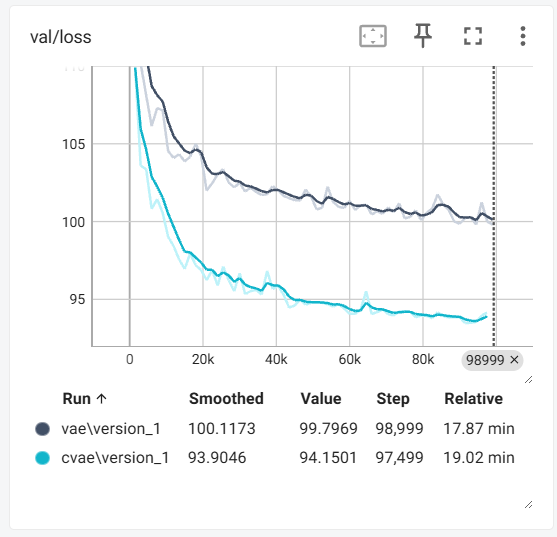

In [ ]:
best_cvae = LitVAE.load_from_checkpoint(
    'checkpoints/cvae/v1/cvae-epoch=062.ckpt',
    model=CVAE(dim_code=MNIST_LATENT_DIMENSIONS, img_size=IMG_SIZE, n_classes=MNIST_CLASSES),
    loss=loss_vae, 
    lr=1e-3
).to(DEVICE)

best_cvae.eval()
print("Checkpoint loaded")

Checkpoint loaded


c:\Users\Efim Plotnikov\PycharmProjects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

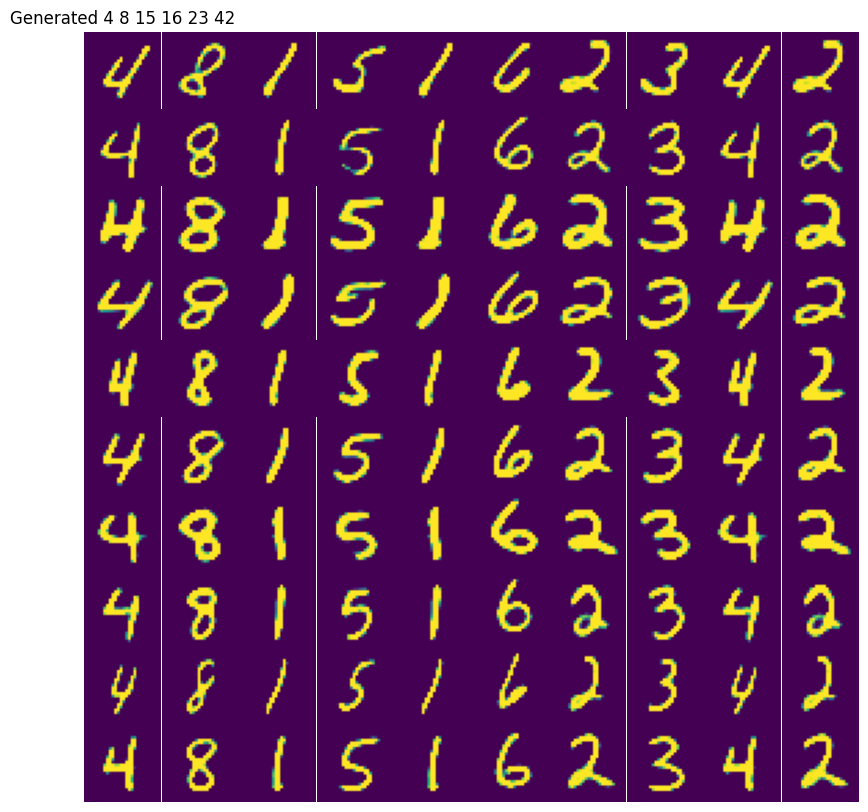

In [84]:
z = np.array([np.random.normal(0, 1, MNIST_LATENT_DIMENSIONS) for i in range(10)])

with torch.no_grad():
    outputs = torch.tensor([])
    for n in [4,8,1,5,1,6,2,3,4,2]:
        z_t = torch.tensor(z).float()
        num_t = torch.ones(z_t.shape[0]).long().mul(n).to(DEVICE)
        output = best_cvae.model.decode(z_t.to(DEVICE), class_num=num_t).detach().cpu()
        outputs = torch.cat([outputs, output], dim=0)
    plot_generated_images(outputs, square_size=10, title=f"Generated 4 8 15 16 23 42")

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

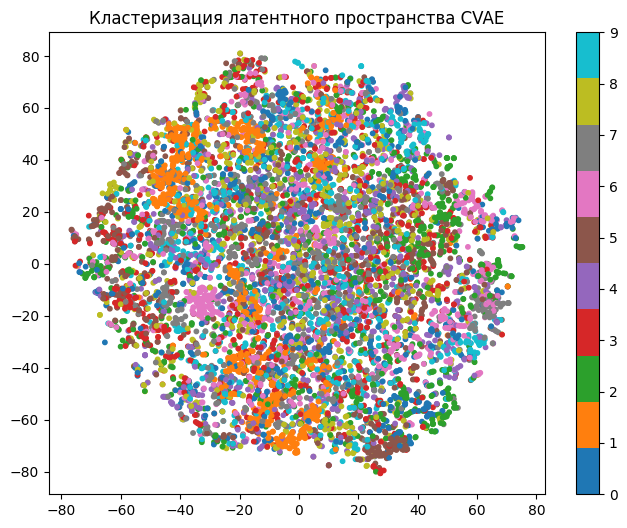

In [87]:
latents_list = []
labels_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)             
        y_batch = y_batch.to(DEVICE)
        mean, logvar = best_cvae.model.encode(X_batch, y_batch)      
        latents_list.append(mean.cpu())
        labels_list.append(y_batch)

latents = torch.cat(latents_list, dim=0).cpu().numpy()
labels = torch.cat(labels_list, dim=0).cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
latents_2d = tsne.fit_transform(latents)

plt.figure(figsize=(8,6))
scatter = plt.scatter(latents_2d[:,0], latents_2d[:,1], c=labels, cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(10))
plt.title("Кластеризация латентного пространства CVAE")
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

**Похоже, хлопушка взорвалась.**

Классы почти неразличимы визуально. Вероятно, это связано с тем, что модель на входе явно получает таргет, и при обучении потоки от разных чисел никак не конфликтуют, модель независимо располагает каждую цифру в латентном пространстве т.к они друг другу не мешаются и не увеличивают лосс при наслоении.


---

Это конец решения. Спасибо за проверку.

# ~~BONUS 1: Denoising (2 балла)~~

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [ ]:
noise_factor = 0.5
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [ ]:
<тут ваш код обучения автоэнкодера на зашумленных картинках. Не забудьте разбить на train/test!>

In [ ]:
<тут проверка, как AE убирает шум с тестовых картинок. Надеюсь, все получилось =)>

# BONUS 2: Image Retrieval (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = <поучите латентные представления картинок из трейна>

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest
lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  code = <получение латентного представления image>

  (distances,),(idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

  return distances, X_train[idx]

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>